# PREPARACION DE LOS DATOS
- TRATAR VALORES NULOS CON CRITERIOS JUSTIFICADOS
- ELIMINAR COLUMNAS QUE NO APORTAR VALOR
- CODIFICAR VARIABLES CATEGORICAS A FORMATO NUMERICO
- CREAR VARIABLES NUEVAS(INGENIERIA DE CARACTERISTICAS) SIMPLES Y UTILES
- ESCALAR VARIABLES NUMERICAS
- DIVIDIR EL DATASET EN CONJUNTOS DE ENTRENAMIENTO Y PRUEBA

ESTE ES EL PUENTE ESNTRE EL EDA Y LOS MODELOS DE MACHINE LEARNING 

In [14]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [15]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

sns.set_theme(style="whitegrid")
df= pd.read_csv("/home/ismael/Escritorio/Curso data science/Clase 3-4 EDA/titanic.csv")
print("Filas y columnas originales: ", df.shape)
df.head()

Filas y columnas originales:  (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# PORQUE PREPARAR LOS DATOS
un modelo machine learning solo entiende numeros, ademas es sensible a valores:
- valores faltantes Nan
- texto sin convertir, deben de transformarse a numeros
- 

In [16]:
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [17]:
# Copiamos el dataframe para no modificar el original
df_prep = df.copy()

# 1) Cabin: se elimina más adelante junto con otras columnas irrelevantes

# 2) Age: imputación con la mediana
mediana_edad = df_prep["Age"].median()
df_prep["Age"] = df_prep["Age"].fillna(mediana_edad)
print("Mediana de edad usada para imputar:", mediana_edad)

# 3) Embarked: imputación con la moda
moda_embarque = df_prep["Embarked"].mode()[0]
df_prep["Embarked"] = df_prep["Embarked"].fillna(moda_embarque)
print("Moda de puerto de embarque usada para imputar:", moda_embarque)

print()
print("Valores nulos después de la imputación:")
print(df_prep.isnull().sum().sort_values(ascending=False))

Mediana de edad usada para imputar: 28.0
Moda de puerto de embarque usada para imputar: S

Valores nulos después de la imputación:
Cabin          687
PassengerId      0
Pclass           0
Survived         0
Name             0
Sex              0
SibSp            0
Age              0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64


# ELIMINAMOS COLUMNAS QUE TIENEN TEXTO


In [18]:
columnas_a_eliminar = ["PassengerId", "Name", "Ticket", "Cabin"]
df_prep = df_prep.drop(columns=columnas_a_eliminar)
# Metodo para eliminar drop()
print("Columnas restantes:", df_prep.columns.tolist())
df_prep.head()

Columnas restantes: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [19]:
# Tamaño total de la familia a bordo (hermanos/cónyuge + padres/hijos + el propio pasajero)
df_prep["FamilySize"] = df_prep["SibSp"] + df_prep["Parch"] + 1

# ¿Viajaba solo?
df_prep["IsAlone"] = (df_prep["FamilySize"] == 1).astype(int)

df_prep[["SibSp", "Parch", "FamilySize", "IsAlone"]].head(10)

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1
5,0,0,1,1
6,0,0,1,1
7,3,1,5,0
8,0,2,3,0
9,1,0,2,0


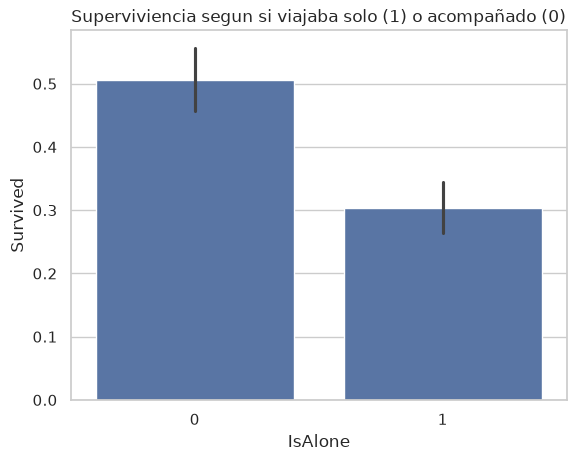

In [20]:
sns.barplot(data=df_prep,x="IsAlone",y="Survived")
plt.title("Superviviencia segun si viajaba solo (1) o acompañado (0)")
plt.show()

# CODIFICACION DE VARIABLES CATEGORICAS

In [21]:
df_prep["Sex"] = df_prep["Sex"].map({"male": 0, "female": 1})
df_prep[["Sex"]].head()

,Sex
0,0
1,1
2,1
3,1
4,0


In [22]:
df_prep = pd.get_dummies(df_prep, columns= ["Embarked"],prefix="Embarked", drop_first=True)
df_prep.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,2,0,False,True
1,1,1,1,38.0,1,0,71.2833,2,0,False,False
2,1,3,1,26.0,0,0,7.9250,1,1,False,True
3,1,1,1,35.0,1,0,53.1000,2,0,False,True
4,0,3,0,35.0,0,0,8.0500,1,1,False,True


In [23]:
columnas_numericas = ["Age", "Fare", "FamilySize"]

scaler = StandardScaler()
df_prep[columnas_numericas] = scaler.fit_transform(df_prep[columnas_numericas])

df_prep[columnas_numericas].describe().round(2)

,Age,Fare,FamilySize
count,891.00,891.00,891.00
mean,0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-2.22,-0.65,-0.56
25%,-0.57,-0.49,-0.56
50%,-0.10,-0.36,-0.56
75%,0.43,-0.02,0.06
max,3.89,9.67,5.64


In [24]:
df_prep

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S
0,0,3,0,-0.565736,1,0,-0.502445,0.059160,0,False,True
1,1,1,1,0.663861,1,0,0.786845,0.059160,0,False,False
2,1,3,1,-0.258337,0,0,-0.488854,-0.560975,1,False,True
3,1,1,1,0.433312,1,0,0.420730,0.059160,0,False,True
4,0,3,0,0.433312,0,0,-0.486337,-0.560975,1,False,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,-0.181487,0,0,-0.386671,-0.560975,1,False,True
887,1,1,1,-0.796286,0,0,-0.044381,-0.560975,1,False,True
888,0,3,1,-0.104637,1,2,-0.176263,1.299429,0,False,True
889,1,1,0,-0.258337,0,0,-0.044381,-0.560975,1,False,False


# DIVISION EN CONJUNTOS DE ENTRENAMIENTO Y PRUEBA
- conjunto de entrenamiento (train): el modelo aprende con estos datos}
- conjunto de prueba (test): se usa solo al final para evaluar que tan bien generaliza el modelo de datos que nunca vio 

se usara un division de 80% 20% de forma estratificada]

In [25]:
X = df_prep.drop(columns=["Survived"])  # variables predictoras
y = df_prep["Survived"]                 # variable objetivo

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print()
print ("Proporcion de sobrevivientes en y_train:", y_train.mean().round(3))
print ("Proporcion de sobrevivientes en y_train:", y_test.mean().round(3))

Tamaño de X_train: (712, 10)
Tamaño de X_test: (179, 10)

Proporcion de sobrevivientes en y_train: 0.383
Proporcion de sobrevivientes en y_train: 0.385


# Guardar los datos preparados (opcional pero recomendado)

In [26]:
# 8. Guardar los datos preparados

X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Archivos guardados: X_train.csv, X_test.csv, y_train.csv, y_test.csv")

Archivos guardados: X_train.csv, X_test.csv, y_train.csv, y_test.csv


# RETO FINAL - FUNCION DE PREPROCESAMIENTO ENCAPSULADA
Para lo aprendido, vamoa a encapsular todo el proceso en unsa sola funcion

In [44]:
def preparar_datos(df_original, guardar_csv=True):
    df_local = df_original.copy()

    # 1. Imputar valores nulos (Age - mediana, Embarked - moda)
    mediana_edad = df_local["Age"].median()
    df_local["Age"] = df_local["Age"].fillna(mediana_edad)

    moda_embarque = df_local["Embarked"].mode()[0]
    df_local["Embarked"] = df_local["Embarked"].fillna(moda_embarque)

    # 2. Eliminar columnas irrelevantes
    columnas_a_eliminar = ["PassengerId", "Name", "Ticket", "Cabin"]
    df_local = df_local.drop(columns=columnas_a_eliminar)

    # 3. Crear FamilySize e IsAlone
    df_local["FamilySize"] = df_local["SibSp"] + df_local["Parch"] + 1
    df_local["IsAlone"] = (df_local["FamilySize"] == 1).astype(int)

    # 4. Codificar Sex (0/1) y Embarked (one-hot)
    df_local["Sex"] = df_local["Sex"].map({"male": 0, "female": 1})
    df_local = pd.get_dummies(df_local, columns=["Embarked"], prefix="Embarked", drop_first=True)

    # 5. Escalar Age, Fare, FamilySize
    columnas_numericas = ["Age", "Fare", "FamilySize"]
    scaler = StandardScaler()
    df_local[columnas_numericas] = scaler.fit_transform(df_local[columnas_numericas])
    
    # 6. Preparar X e y, y dividir en train/test (80/20) estratificado
    X = df_local.drop(columns=["Survived"])
    y = df_local["Survived"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # 7. Guardar los archivos CSV
    
    X_train.to_csv("X1_train.csv", index=False)
    X_test.to_csv("X1_test.csv", index=False)
    y_train.to_csv("y1_train.csv", index=False)
    y_test.to_csv("y1_test.csv", index=False)
    print("Archivos guardados exitosamente: X1_train.csv, X1_test.csv, y1_train.csv, y1_test.csv")

    print("Se ha terminado de procesar los datos.")
    

In [45]:
preparar_datos(df)

Archivos guardados exitosamente: X1_train.csv, X1_test.csv, y1_train.csv, y1_test.csv
Se ha terminado de procesar los datos.
